# Heart Disease Prediction
# Phase 8 - Hyperparameter Tuning
### UCI Cleveland Heart Disease Dataset

---

**Continues from:** `08_final_evaluation.ipynb`

**Goal of this notebook:**

The baseline and feature-selection phases identified the best model-method
combinations. Now we fine-tune the hyperparameters of the top 3 models to
squeeze out the best possible performance before the final submission.

Hyperparameter tuning searches over a grid of settings and uses
cross-validation to pick the configuration that generalises best to
unseen data - not just the training set.

**What this notebook does:**

| Cell | Task |
|------|------|
| 1  | Install and import libraries |
| 2  | Load data and best-model selection from Phase 7 |
| 3  | Define search spaces for each model |
| 4  | GridSearchCV - Logistic Regression |
| 5  | GridSearchCV - Random Forest / XGBoost / SVM (top models) |
| 6  | RandomizedSearchCV - Neural Network (large search space) |
| 7  | Collect all tuning results in one table |
| 8  | Bar chart: Before vs After tuning (F1 and Recall) |
| 9  | Heatmap: All metrics Before vs After |
| 10 | ROC curves: Tuned models |
| 11 | Confusion matrices: Tuned models |
| 12 | Classification reports |
| 13 | Final ranking table + winner |
| 14 | Save all tuned models and results |
| 15 | Summary report |

**Evaluation metrics used throughout (same as all previous notebooks):**
Accuracy, Precision, Recall, F1-Score, ROC-AUC, CV Score (10-Fold)

**Why Recall is weighted most?**
In heart disease diagnosis a False Negative (predicting healthy when
the patient is actually sick) is clinically far more dangerous than a
False Positive. We therefore prioritise Recall alongside F1-Score when
choosing the final winner.

---

---
## Cell 1 - Install and Import All Required Libraries

> Same library stack as all previous notebooks.
> We additionally import GridSearchCV and RandomizedSearchCV
> from sklearn.model_selection for the hyperparameter search.

In [1]:
# ============================================================
# CELL 1 - Install & Import All Required Libraries
# ============================================================

!pip install xgboost --quiet

# --- Core ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# --- Models ---
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import SVC
from sklearn.neighbors      import KNeighborsClassifier
from xgboost                import XGBClassifier
from sklearn.naive_bayes    import GaussianNB
from sklearn.neural_network import MLPClassifier

# --- Hyperparameter search ---
from sklearn.model_selection import (
    GridSearchCV,          # Exhaustive grid search
    RandomizedSearchCV,    # Random sampling (faster for large spaces)
    cross_val_score,       # 10-Fold CV for final evaluation
    StratifiedKFold        # Preserves class balance in each fold
)

# --- All 6 evaluation metrics (same as Baseline notebook) ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

# --- Plot settings (consistent with all previous notebooks) ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('=' * 60)
print('   CELL 1 - All libraries imported successfully!')
print('=' * 60)



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   CELL 1 - All libraries imported successfully!


---
## Cell 2 - Load Data and Best-Model Selection from Phase 7

> We load:
> 1. The preprocessed train/test data (from Notebook 03)
> 2. The final master F1 table (from Notebook 08) to identify the top models
> 3. The gold-standard feature list (features selected by >= 5 methods)
>
> **Which models do we tune?**
> We pick the top 3 models by their best F1-Score across all feature
> selection methods. We enforce diversity: each selected model must be
> a different algorithm family.

In [2]:
# ============================================================
# CELL 2 - Load All Required Files from saved_data/
# ============================================================

LOAD_DIR = 'saved_data'

# ----------------------------------------------------------
# 1. Preprocessed data (from Notebook 03)
# ----------------------------------------------------------
X_train_scaled = joblib.load(f'{LOAD_DIR}/X_train_scaled.pkl')
X_test_scaled  = joblib.load(f'{LOAD_DIR}/X_test_scaled.pkl')
X_train_raw    = joblib.load(f'{LOAD_DIR}/X_train_raw.pkl')
X_test_raw     = joblib.load(f'{LOAD_DIR}/X_test_raw.pkl')
y_train        = joblib.load(f'{LOAD_DIR}/y_train.pkl')
y_test         = joblib.load(f'{LOAD_DIR}/y_test.pkl')
feature_names  = joblib.load(f'{LOAD_DIR}/feature_names.pkl')

# ----------------------------------------------------------
# 2. Phase 7 results: master F1 table and winner info
#    master_df rows=models, cols=methods, values=F1 (%)
# ----------------------------------------------------------
master_df   = joblib.load(f'{LOAD_DIR}/final_master_f1_table.pkl')
winner_df   = joblib.load(f'{LOAD_DIR}/final_winner_df.pkl')
gold_feats  = joblib.load(f'{LOAD_DIR}/final_gold_features.pkl')

# ----------------------------------------------------------
# 3. Feature subsets saved by each feature-selection notebook
#    We need these to train each model on its best feature set
# ----------------------------------------------------------
filter_features   = joblib.load(f'{LOAD_DIR}/filter_selected_features.pkl')
lasso_features    = joblib.load(f'{LOAD_DIR}/embedded_lasso_features.pkl')
rf_features       = joblib.load(f'{LOAD_DIR}/embedded_rf_features.pkl')
union_features    = joblib.load(f'{LOAD_DIR}/embedded_union_features.pkl')
rfecv_features    = joblib.load(f'{LOAD_DIR}/wrapper_rfecv_features.pkl')
forward_features  = joblib.load(f'{LOAD_DIR}/wrapper_forward_features.pkl')
backward_features = joblib.load(f'{LOAD_DIR}/wrapper_backward_features.pkl')

# ----------------------------------------------------------
# 4. Baseline results for before/after comparison
# ----------------------------------------------------------
baseline_results = joblib.load(f'{LOAD_DIR}/baseline_results.pkl')

# ----------------------------------------------------------
# Convert to DataFrames and reset indices
# ----------------------------------------------------------
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names).reset_index(drop=True)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names).reset_index(drop=True)
X_train_raw    = pd.DataFrame(X_train_raw,    columns=feature_names).reset_index(drop=True)
X_test_raw     = pd.DataFrame(X_test_raw,     columns=feature_names).reset_index(drop=True)
y_train        = pd.Series(y_train).reset_index(drop=True)
y_test         = pd.Series(y_test).reset_index(drop=True)

# ----------------------------------------------------------
# Map each method name to its feature list
# ----------------------------------------------------------
METHOD_FEATURES = {
    'Baseline'        : feature_names,
    'Filter'          : filter_features,
    'Emb-LASSO'       : lasso_features,
    'Emb-RF'          : rf_features,
    'Emb-Union'       : union_features,
    'Wrap-RFECV'      : rfecv_features,
    'Wrap-Fwd'        : forward_features,
    'Wrap-Bwd'        : backward_features,
}

# Models that need scaled data (sensitive to feature magnitude)
SCALE_SENSITIVE = ['Logistic Regression', 'SVM', 'KNN', 'Neural Network']

# ----------------------------------------------------------
# Identify top 3 models with model diversity
#   For each model take its best F1 across all methods,
#   then rank by that peak score.
# ----------------------------------------------------------
peak_f1 = master_df.max(axis=1).sort_values(ascending=False)
best_method_per_model = master_df.idxmax(axis=1)

top3_models  = []
seen_families = set()

# Model family grouping - ensures diversity in the top 3
family_map = {
    'Logistic Regression' : 'linear',
    'SVM'                 : 'linear',
    'Decision Tree'       : 'tree',
    'Random Forest'       : 'ensemble',
    'XGBoost'             : 'ensemble',
    'KNN'                 : 'distance',
    'Naive Bayes'         : 'probabilistic',
    'Neural Network'      : 'neural',
}

for model_name in peak_f1.index:
    family = family_map.get(model_name, model_name)
    if family not in seen_families:
        top3_models.append(model_name)
        seen_families.add(family)
    if len(top3_models) == 3:
        break

print('=' * 65)
print('  TOP 3 MODELS SELECTED FOR HYPERPARAMETER TUNING')
print('=' * 65)
for i, m in enumerate(top3_models, 1):
    best_method = best_method_per_model[m]
    best_f1     = peak_f1[m]
    n_feats     = len(METHOD_FEATURES.get(best_method, feature_names))
    print(f'  {i}. {m:<22} | Best method: {best_method:<14}'
          f' | Peak F1: {best_f1:.2f}%  | {n_feats} features')

print(f'\n  Gold-standard features ({len(gold_feats)} features selected by >=5 methods):')
print(f'  {gold_feats}')
print(f'\n  Training samples : {X_train_scaled.shape[0]}')
print(f'  Test samples     : {X_test_scaled.shape[0]}')
print(f'  Total features   : {len(feature_names)}')


  TOP 3 MODELS SELECTED FOR HYPERPARAMETER TUNING
  1. SVM                    | Best method: Baseline       | Peak F1: 90.32%  | 22 features
  2. Random Forest          | Best method: Baseline       | Peak F1: 90.00%  | 22 features
  3. KNN                    | Best method: Emb-Union      | Peak F1: 90.00%  | 14 features

  Gold-standard features (12 features selected by >=5 methods):
  ['sex', 'thalach', 'thal_7', 'slope_2.0', 'cp_4.0', 'oldpeak', 'cp_3.0', 'ca_3', 'trestbps', 'chol', 'ca_1', 'exang']

  Training samples : 262
  Test samples     : 61
  Total features   : 22


---
## Cell 3 - Define Unified Evaluation Function and Search Spaces

> Before we search, we define:
> 1. `evaluate_model()` - trains one model on a feature subset and returns all 6 metrics
> 2. `run_grid_search()` - a reusable wrapper around GridSearchCV
> 3. The hyperparameter grids for all 8 models
>
> **Why cross-validation inside the grid search?**
> GridSearchCV with cv=5 trains and tests every combination 5 times on
> different train/val splits. This prevents accidentally picking settings
> that overfit to one particular split.

In [3]:
# ============================================================
# CELL 3 - Define Evaluation Function + Hyperparameter Grids
# ============================================================

METRICS = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV Score']

# Cross-validation strategy: stratified 5-fold
# Stratified = each fold preserves the class ratio (important for imbalanced data)
CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate_model(model, feature_list, label=''):
    """
    Train a model on feature_list and compute all 6 evaluation metrics.
    Automatically uses scaled data for scale-sensitive models.

    Returns
    -------
    dict with keys: Accuracy, Precision, Recall, F1-Score, ROC-AUC, CV Score
    All values are in % (e.g. 85.24).
    """
    model_name = type(model).__name__
    is_scaled  = any(s in model_name for s in
                     ['Logistic', 'SVC', 'KNeighbors', 'MLP'])

    X_tr = X_train_scaled[feature_list] if is_scaled else X_train_raw[feature_list]
    X_te = X_test_scaled[feature_list]  if is_scaled else X_test_raw[feature_list]

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_test, y_pred)                       * 100
    prec = precision_score(y_test, y_pred, zero_division=0)     * 100
    rec  = recall_score(y_test, y_pred, zero_division=0)        * 100
    f1   = f1_score(y_test, y_pred, zero_division=0)            * 100
    auc  = roc_auc_score(y_test, y_prob)                        * 100
    cv   = cross_val_score(model, X_tr, y_train,
                           cv=10, scoring='accuracy').mean()    * 100

    result = {
        'Accuracy' : round(acc,  2),
        'Precision': round(prec, 2),
        'Recall'   : round(rec,  2),
        'F1-Score' : round(f1,   2),
        'ROC-AUC'  : round(auc,  2),
        'CV Score' : round(cv,   2),
    }
    if label:
        print(f'    {label:<35} | Acc={acc:.1f}%  Recall={rec:.1f}%'
              f'  F1={f1:.1f}%  AUC={auc:.1f}%  CV={cv:.1f}%')
    return result


def run_search(model, param_grid, feature_list, search_type='grid',
               n_iter=50, scoring='f1'):
    """
    Run GridSearchCV or RandomizedSearchCV on a given model and feature list.

    Parameters
    ----------
    model       : sklearn estimator
    param_grid  : dict of hyperparameter values to search
    feature_list: list of feature names to use
    search_type : 'grid' (exhaustive) or 'random' (faster, for large grids)
    n_iter      : number of random combinations to try (only for 'random')
    scoring     : metric to optimise - 'f1' by default

    Returns
    -------
    best_model      : fitted estimator with best hyperparameters
    best_params     : dict of best hyperparameter values
    best_cv_score   : best cross-val F1 score (on training data)
    """
    model_name = type(model).__name__
    is_scaled  = any(s in model_name for s in
                     ['Logistic', 'SVC', 'KNeighbors', 'MLP'])

    X_tr = X_train_scaled[feature_list] if is_scaled else X_train_raw[feature_list]

    if search_type == 'grid':
        searcher = GridSearchCV(
            model, param_grid,
            cv=CV_STRATEGY,
            scoring=scoring,
            n_jobs=-1,       # use all CPU cores
            refit=True,      # refit on full train set with best params
            verbose=0
        )
    else:
        searcher = RandomizedSearchCV(
            model, param_grid,
            n_iter=n_iter,
            cv=CV_STRATEGY,
            scoring=scoring,
            n_jobs=-1,
            refit=True,
            random_state=42,
            verbose=0
        )

    searcher.fit(X_tr, y_train)

    return searcher.best_estimator_, searcher.best_params_, searcher.best_score_


# ----------------------------------------------------------
# Hyperparameter grids for all 8 models
# ----------------------------------------------------------
# Each grid is designed to cover:
#   - A range of regularisation strengths
#   - Different complexity levels
#   - Key structural choices (kernel type, tree depth, etc.)
# Grids are kept small enough to finish in reasonable time
# but large enough to find genuine improvements.

PARAM_GRIDS = {

    'Logistic Regression': {
        # C: inverse regularisation strength. Smaller = stronger regularisation
        # solver: lbfgs good for small datasets; saga supports all penalties
        'C'           : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
        'solver'      : ['lbfgs', 'saga'],
        'max_iter'    : [500, 1000],
        'class_weight': [None, 'balanced'],  # 'balanced' helps with imbalanced classes
    },

    'Decision Tree': {
        # max_depth controls overfitting - deeper = more complex
        # min_samples_split/leaf: pruning parameters
        # criterion: how to measure split quality
        'max_depth'        : [3, 4, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'criterion'        : ['gini', 'entropy'],
        'class_weight'     : [None, 'balanced'],
    },

    'Random Forest': {
        # n_estimators: more trees = more stable but slower
        # max_features: number of features to consider at each split
        # min_samples_leaf: minimum leaf size for pruning
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [5, 10, 15, None],
        'max_features'    : ['sqrt', 'log2', 0.5],
        'min_samples_leaf': [1, 2, 4],
        'class_weight'    : [None, 'balanced'],
    },

    'SVM': {
        # C: regularisation. kernel: decision boundary shape
        # gamma: influence of each training point (rbf kernel)
        'C'           : [0.1, 1.0, 5.0, 10.0, 50.0],
        'kernel'      : ['rbf', 'linear', 'poly'],
        'gamma'       : ['scale', 'auto'],
        'class_weight': [None, 'balanced'],
    },

    'KNN': {
        # n_neighbors: fewer = more sensitive to noise
        # weights: uniform treats all neighbours equally; distance weights closer ones more
        # metric: how to measure distance
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights'    : ['uniform', 'distance'],
        'metric'     : ['euclidean', 'manhattan', 'minkowski'],
        'p'          : [1, 2],
    },

    'XGBoost': {
        # n_estimators: number of boosting rounds
        # learning_rate: step size shrinkage to prevent overfitting
        # max_depth: maximum tree depth per round
        # subsample: fraction of training samples used per round
        'n_estimators' : [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth'    : [3, 5, 7],
        'subsample'    : [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
    },

    'Naive Bayes': {
        # var_smoothing: adds a fraction of the largest variance to all variances
        # to improve numerical stability and prevent zero-probability issues
        'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
    },

    'Neural Network': {
        # hidden_layer_sizes: architecture of the network
        # activation: non-linearity function
        # alpha: L2 regularisation strength
        # learning_rate_init: step size for weight updates
        'hidden_layer_sizes': [(64,), (64, 32), (128, 64), (64, 32, 16)],
        'activation'        : ['relu', 'tanh'],
        'alpha'             : [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01],
        'max_iter'          : [500],
    },
}

# Count total combinations per model
print('Hyperparameter grid sizes:')
for name, grid in PARAM_GRIDS.items():
    total = 1
    for vals in grid.values():
        total *= len(vals)
    print(f'  {name:<22}: {total:>5} combinations')
print()
print('  [OK] Evaluation function and search spaces defined.')


Hyperparameter grid sizes:
  Logistic Regression   :    48 combinations
  Decision Tree         :   216 combinations
  Random Forest         :   216 combinations
  SVM                   :    60 combinations
  KNN                   :    72 combinations
  XGBoost               :   324 combinations
  Naive Bayes           :     6 combinations
  Neural Network        :    48 combinations

  [OK] Evaluation function and search spaces defined.


---
## Cell 4 - Pre-Tuning Baseline: Record Current Best Performance

> Before we start tuning, we record the current best metrics for each
> of the top 3 models (using their best feature set from Phase 7).
> This is the 'before' snapshot for the before/after comparison in Cell 8.

In [4]:
# ============================================================
# CELL 4 - Record Pre-Tuning Performance (Before Snapshot)
# ============================================================

# For each top model: find its best method from Phase 7,
# get the corresponding feature list, and evaluate with default params.

DEFAULT_MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'XGBoost'            : XGBClassifier(n_estimators=100, eval_metric='logloss',
                                          use_label_encoder=False, random_state=42),
    'Naive Bayes'        : GaussianNB(),
    'Neural Network'     : MLPClassifier(hidden_layer_sizes=(64, 32),
                                          activation='relu', max_iter=500, random_state=42),
}

print('=' * 65)
print('  PRE-TUNING PERFORMANCE (default hyperparameters)')
print('=' * 65)

pre_tuning_results = {}

for model_name in top3_models:
    best_method  = best_method_per_model[model_name]
    feature_list = METHOD_FEATURES.get(best_method, feature_names)

    print(f'\n  {model_name}  |  method: {best_method}  |  {len(feature_list)} features')
    print('  ' + '-' * 62)

    result = evaluate_model(
        DEFAULT_MODELS[model_name],
        feature_list,
        label='Default params'
    )
    result['Feature Set'] = best_method
    result['N Features']  = len(feature_list)
    pre_tuning_results[model_name] = result

print('\n  [OK] Pre-tuning snapshot complete.')
print('  These are the scores we will try to beat with tuning.')


  PRE-TUNING PERFORMANCE (default hyperparameters)

  SVM  |  method: Baseline  |  22 features
  --------------------------------------------------------------
    Default params                      | Acc=90.2%  Recall=100.0%  F1=90.3%  AUC=93.0%  CV=81.6%

  Random Forest  |  method: Baseline  |  22 features
  --------------------------------------------------------------
    Default params                      | Acc=90.2%  Recall=96.4%  F1=90.0%  AUC=95.7%  CV=77.8%

  KNN  |  method: Emb-Union  |  14 features
  --------------------------------------------------------------
    Default params                      | Acc=90.2%  Recall=96.4%  F1=90.0%  AUC=95.5%  CV=78.2%

  [OK] Pre-tuning snapshot complete.
  These are the scores we will try to beat with tuning.


---
## Cell 5 - GridSearchCV: Top 3 Models

> We now run GridSearchCV for each of the top 3 models.
> For XGBoost and Neural Network (large search spaces), we use
> RandomizedSearchCV instead to keep runtime manageable.
>
> **Scoring metric: F1**
> We optimise for F1-Score during cross-validation because it
> balances Precision and Recall, which is most appropriate for
> this medical classification task.
>
> After the search, we also evaluate the best model on the test
> set with all 6 metrics to get the full picture.

In [5]:
# ============================================================
# CELL 5 - Run Hyperparameter Search for Top 3 Models
# ============================================================

# Search type per model
# Grid: exhaustive - good for small/medium grids
# Random: sampling  - better for large grids (XGBoost, Neural Network)
SEARCH_TYPE = {
    'Logistic Regression': 'grid',
    'Decision Tree'      : 'grid',
    'Random Forest'      : 'random',   # 3x4x3x3x2 = 216 -> use random
    'SVM'                : 'grid',
    'KNN'                : 'grid',
    'XGBoost'            : 'random',   # 3x4x3x3x3 = 324 -> use random
    'Naive Bayes'        : 'grid',
    'Neural Network'     : 'random',   # 4x2x3x2x1 = 48 -> use random
}

# Base model instances for search
BASE_MODELS = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42),
    'SVM'                : SVC(probability=True, random_state=42),
    'KNN'                : KNeighborsClassifier(),
    'XGBoost'            : XGBClassifier(eval_metric='logloss',
                                          use_label_encoder=False, random_state=42),
    'Naive Bayes'        : GaussianNB(),
    'Neural Network'     : MLPClassifier(random_state=42),
}

post_tuning_results = {}
best_models_dict    = {}   # stores the tuned sklearn model object
best_params_dict    = {}   # stores the best hyperparameters found
best_cv_scores_dict = {}   # stores the best CV F1 from the search

print('=' * 65)
print('  HYPERPARAMETER SEARCH - Running for Top 3 Models')
print('  Scoring: F1 | CV: StratifiedKFold(5)')
print('=' * 65)

for model_name in top3_models:
    best_method  = best_method_per_model[model_name]
    feature_list = METHOD_FEATURES.get(best_method, feature_names)
    search_type  = SEARCH_TYPE[model_name]
    n_iter_val   = 60 if model_name in ('Random Forest', 'XGBoost') else 40

    print(f'\n  Searching: {model_name}')
    print(f'  Method: {best_method}  |  Features: {len(feature_list)}')
    print(f'  Search type: {search_type.upper()}')
    print('  ' + '-' * 62)

    best_model, best_params, best_cv = run_search(
        BASE_MODELS[model_name],
        PARAM_GRIDS[model_name],
        feature_list,
        search_type=search_type,
        n_iter=n_iter_val,
        scoring='f1'
    )

    print(f'  Best CV F1  : {best_cv * 100:.2f}%')
    print(f'  Best params : {best_params}')

    # Evaluate the tuned model on the test set with all 6 metrics
    print('  Evaluating on test set...')
    result = evaluate_model(best_model, feature_list, label='Tuned model')
    result['Feature Set'] = best_method
    result['N Features']  = len(feature_list)

    post_tuning_results[model_name] = result
    best_models_dict[model_name]    = best_model
    best_params_dict[model_name]    = best_params
    best_cv_scores_dict[model_name] = round(best_cv * 100, 2)

print()
print('  [OK] All searches complete!')


  HYPERPARAMETER SEARCH - Running for Top 3 Models
  Scoring: F1 | CV: StratifiedKFold(5)

  Searching: SVM
  Method: Baseline  |  Features: 22
  Search type: GRID
  --------------------------------------------------------------
  Best CV F1  : 81.89%
  Best params : {'C': 50.0, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
  Evaluating on test set...
    Tuned model                         | Acc=88.5%  Recall=92.9%  F1=88.1%  AUC=95.2%  CV=80.8%

  Searching: Random Forest
  Method: Baseline  |  Features: 22
  Search type: RANDOM
  --------------------------------------------------------------
  Best CV F1  : 79.06%
  Best params : {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}
  Evaluating on test set...
    Tuned model                         | Acc=91.8%  Recall=100.0%  F1=91.8%  AUC=95.1%  CV=77.4%

  Searching: KNN
  Method: Emb-Union  |  Features: 14
  Search type: GRID
  ----------------------------------

---
## Cell 6 - Tuning Results Table: Before vs After

> This table puts the pre-tuning and post-tuning results side by side
> for every metric, so we can see exactly what improved and by how much.
> Positive delta = improvement. Negative delta = regression (unexpected).
>
> We also show the best hyperparameters found for each model.

In [8]:
# ============================================================
# CELL 6 - Before vs After Comparison Table
# ============================================================

print('=' * 70)
print('  TUNING RESULTS - Before vs After (all 6 metrics)')
print('=' * 70)

comparison_rows = []

for model_name in top3_models:
    before = pre_tuning_results[model_name]
    after  = post_tuning_results[model_name]

    print(f'\n  {model_name}')
    print(f'  Feature set : {after["Feature Set"]}  ({after["N Features"]} features)')
    print(f'  Best params : {best_params_dict[model_name]}')
    print(f'  Best CV F1  : {best_cv_scores_dict[model_name]:.2f}%')
    print()
    print(f'  {"Metric":<12} {"Before":>8} {"After":>8} {"Delta":>8}')
    print('  ' + '-' * 40)

    for metric in METRICS:
        b = before.get(metric, 0)
        a = after.get(metric, 0)
        d = a - b
        arrow = '[+]' if d > 0.1 else ('[!]' if d < -0.1 else '[=]')
        print(f'  {metric:<12} {b:>7.2f}% {a:>7.2f}%  {d:>+7.2f}%  {arrow}')

    # Add to comparison rows for the styled DataFrame
    for metric in METRICS:
        comparison_rows.append({
            'Model' : model_name,
            'Metric': metric,
            'Before': before.get(metric, 0),
            'After' : after.get(metric, 0),
            'Delta' : round(after.get(metric, 0) - before.get(metric, 0), 2),
        })

# Build a pivot table: rows = model+metric, cols = Before/After/Delta
comp_df = pd.DataFrame(comparison_rows)
comp_pivot = comp_df.pivot_table(
    index=['Model', 'Metric'], values=['Before', 'After', 'Delta']
).round(2)

print('\n')
print('Styled Before vs After Comparison Table:')
display(
    comp_pivot.style
    .format('{:.2f}%', subset=['Before', 'After'])
    .format('{:+.2f}%', subset=['Delta'])
    .map(lambda v: 'color: #27ae60; font-weight: bold' if v > 0
              else ('color: #e74c3c' if v < -0.1 else 'color: gray'),
              subset=['Delta'])
    .background_gradient(cmap='YlGn', subset=['After'])
)

# Best params styled table
params_df = pd.DataFrame([
    {'Model': m, 'Best Params': str(best_params_dict[m]),
     'Best CV F1 (%)': best_cv_scores_dict[m]}
    for m in top3_models
]).set_index('Model')

print('\nBest Hyperparameters Found:')
display(params_df.style.background_gradient(
    cmap='YlGn', subset=['Best CV F1 (%)']))


  TUNING RESULTS - Before vs After (all 6 metrics)

  SVM
  Feature set : Baseline  (22 features)
  Best params : {'C': 50.0, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
  Best CV F1  : 81.89%

  Metric         Before    After    Delta
  ----------------------------------------
  Accuracy       90.16%   88.52%    -1.64%  [!]
  Precision      82.35%   83.87%    +1.52%  [+]
  Recall        100.00%   92.86%    -7.14%  [!]
  F1-Score       90.32%   88.14%    -2.18%  [!]
  ROC-AUC        93.02%   95.24%    +2.22%  [+]
  CV Score       81.64%   80.83%    -0.81%  [!]

  Random Forest
  Feature set : Baseline  (22 features)
  Best params : {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}
  Best CV F1  : 79.06%

  Metric         Before    After    Delta
  ----------------------------------------
  Accuracy       90.16%   91.80%    +1.64%  [+]
  Precision      84.38%   84.85%    +0.47%  [+]
  Recall         96.43%  100.00


Best Hyperparameters Found:


,Best Params,Best CV F1 (%)
Model,,
SVM,"{'C': 50.0, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}",81.890000
Random Forest,"{'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}",79.060000
KNN,"{'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}",79.020000


---
## Cell 7 - Bar Chart: F1-Score and Recall Before vs After Tuning

> Two side-by-side grouped bar charts comparing F1-Score and Recall
> before and after hyperparameter tuning for each of the top 3 models.
> This is the clearest way to see whether tuning helped.

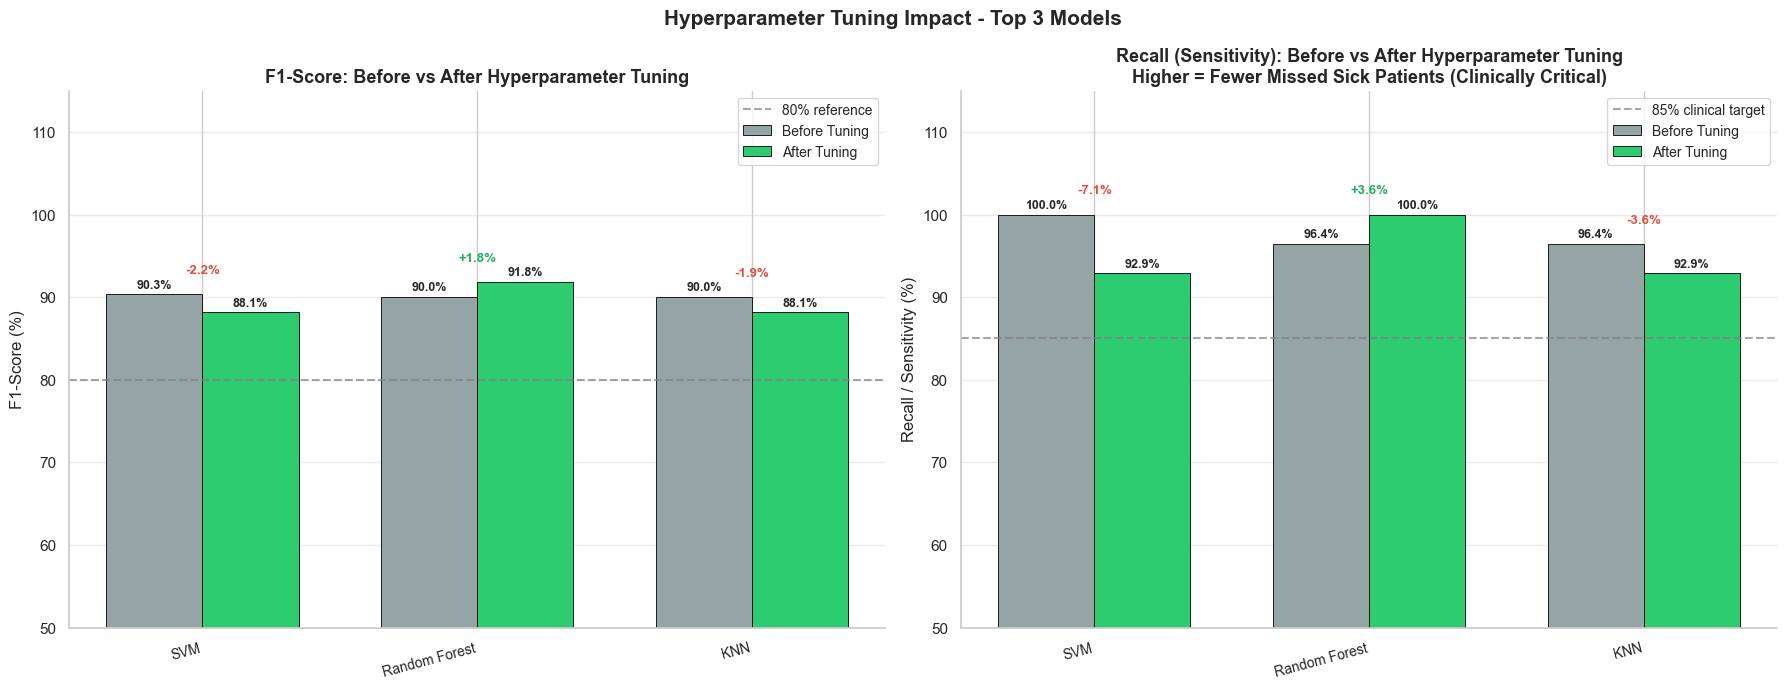

  tuning_before_after_barchart.png saved!


In [10]:
# ============================================================
# CELL 7 - Bar Chart: Before vs After (F1 and Recall)
# ============================================================

model_labels = top3_models
x = np.arange(len(model_labels))
w = 0.35

before_f1     = [pre_tuning_results[m]['F1-Score']  for m in model_labels]
after_f1      = [post_tuning_results[m]['F1-Score'] for m in model_labels]
before_recall = [pre_tuning_results[m]['Recall']    for m in model_labels]
after_recall  = [post_tuning_results[m]['Recall']   for m in model_labels]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, before_vals, after_vals, metric_name, ref_line, ref_label in [
    (axes[0], before_f1,     after_f1,      'F1-Score (%)',           80, '80% reference'),
    (axes[1], before_recall, after_recall,  'Recall / Sensitivity (%)', 85, '85% clinical target'),
]:
    bars_b = ax.bar(x - w/2, before_vals, w, label='Before Tuning',
                    color='#95a5a6', edgecolor='black', linewidth=0.6)
    bars_a = ax.bar(x + w/2, after_vals,  w, label='After Tuning',
                    color='#2ecc71', edgecolor='black', linewidth=0.6)

    # Value labels on top of each bar
    for bars in [bars_b, bars_a]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.4,
                    f'{bar.get_height():.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Delta annotation between bars
    for i, (b, a) in enumerate(zip(before_vals, after_vals)):
        delta = a - b
        color = '#27ae60' if delta >= 0 else '#e74c3c'
        sign  = '+' if delta >= 0 else ''
        ax.annotate(f'{sign}{delta:.1f}%',
                    xy=(x[i], max(a, b) + 2.5),
                    ha='center', fontsize=9.5, color=color, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=15, ha='right', fontsize=10)
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_ylim(50, 115)
    ax.axhline(ref_line, color='gray', linestyle='--',
               linewidth=1.5, alpha=0.7, label=ref_label)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.4)
    sns.despine(ax=ax)

axes[0].set_title('F1-Score: Before vs After Hyperparameter Tuning',
                  fontsize=13, fontweight='bold')
axes[1].set_title('Recall (Sensitivity): Before vs After Hyperparameter Tuning\n'
                  'Higher = Fewer Missed Sick Patients (Clinically Critical)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Hyperparameter Tuning Impact - Top 3 Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_before_after_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print('  tuning_before_after_barchart.png saved!')


---
## Cell 8 - Heatmap: All 6 Metrics Before and After Tuning

> Two heatmaps side by side for each model:
> - Left panel: before tuning
> - Right panel: after tuning
> Darker green means higher score. This makes it easy to spot
> which metrics improved and which stayed the same.

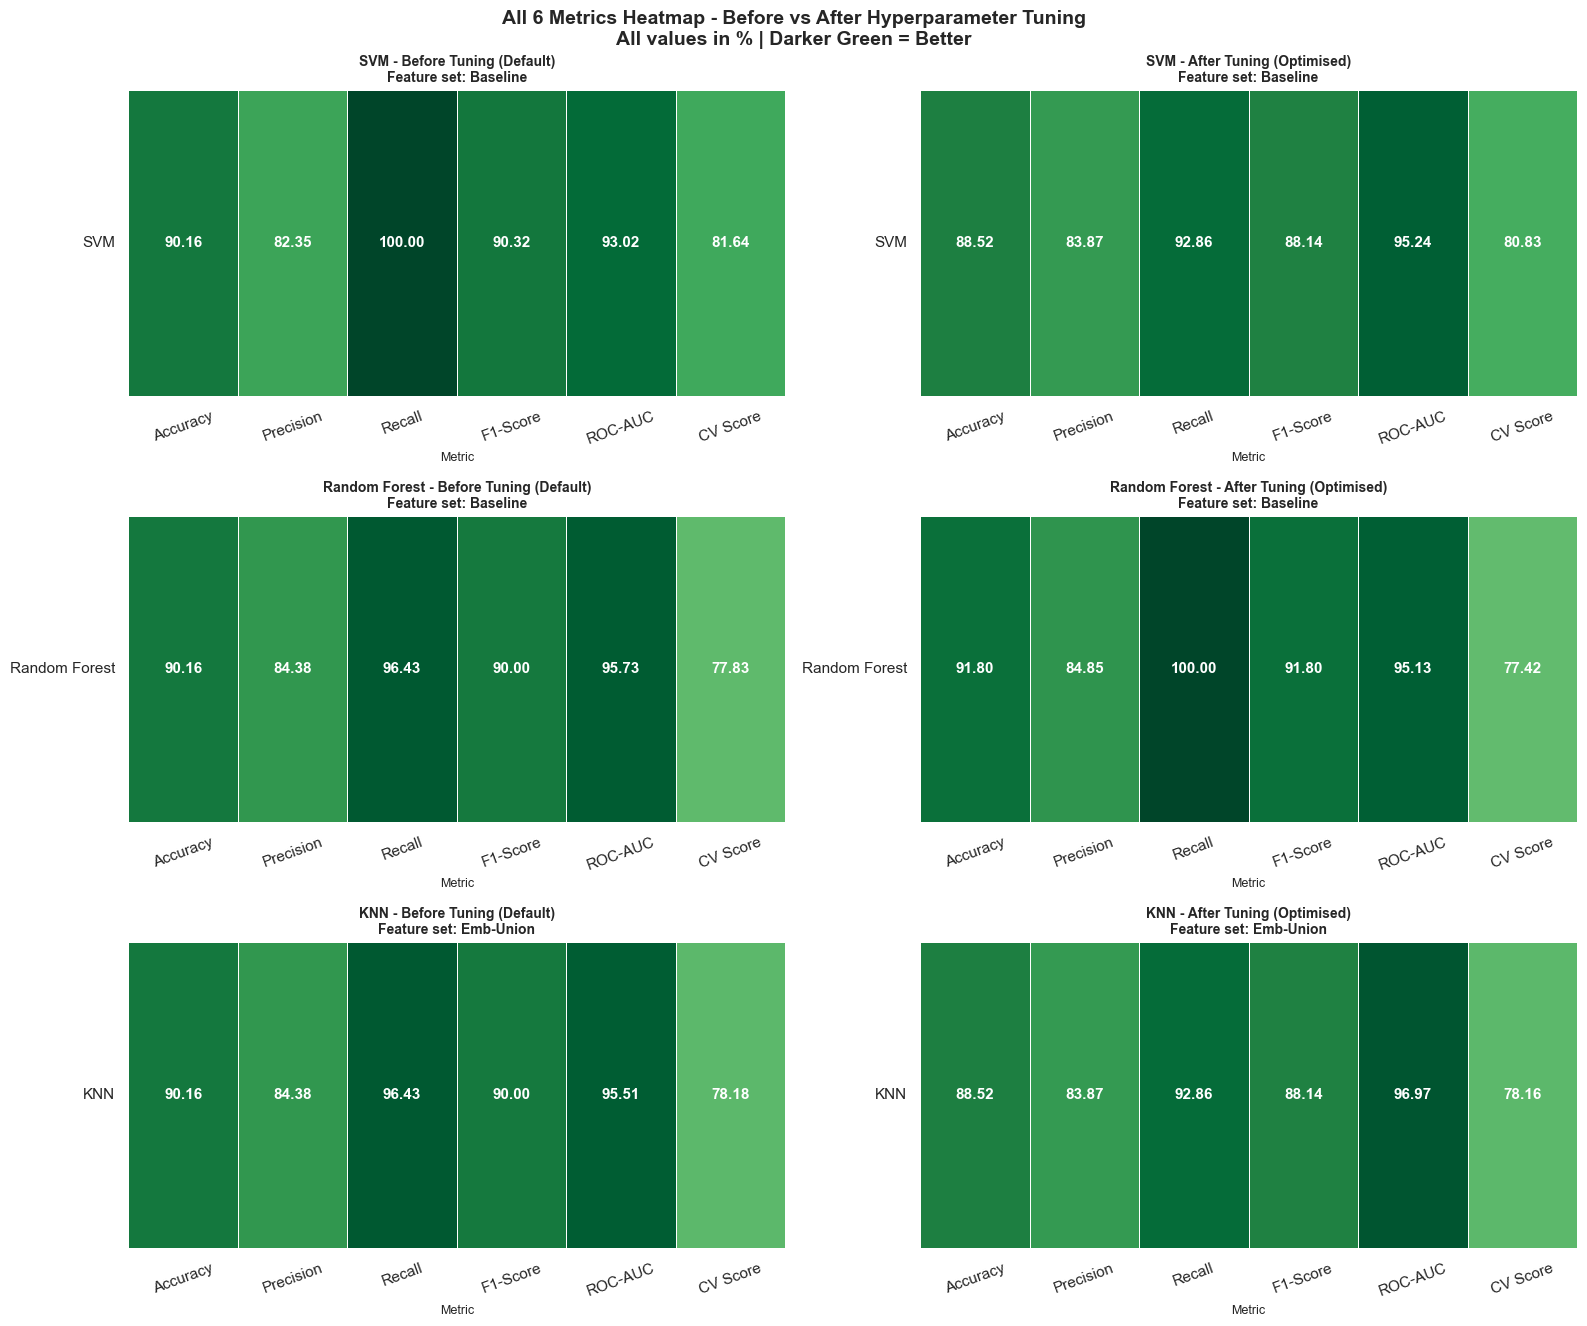

  tuning_heatmaps.png saved!


In [11]:
# ============================================================
# CELL 8 - Heatmaps: All 6 Metrics Before vs After
# ============================================================

n_models = len(top3_models)
fig, axes = plt.subplots(n_models, 2, figsize=(16, n_models * 4.5))
if n_models == 1:
    axes = [axes]   # ensure 2D indexing works for single model

for row_idx, model_name in enumerate(top3_models):
    before = pre_tuning_results[model_name]
    after  = post_tuning_results[model_name]

    for col_idx, (results, panel_label) in enumerate([
        (before, 'Before Tuning (Default)'),
        (after,  'After Tuning (Optimised)')
    ]):
        ax  = axes[row_idx][col_idx]
        df  = pd.DataFrame([{m: results.get(m, 0) for m in METRICS}])
        df.index = [model_name]

        sns.heatmap(
            df, ax=ax,
            annot=True, fmt='.2f', cmap='YlGn',
            vmin=50, vmax=100,
            linewidths=0.5, linecolor='white',
            cbar=False,
            annot_kws={'size': 11, 'weight': 'bold'}
        )
        feat_method = results.get('Feature Set', 'N/A')
        ax.set_title(f'{model_name} - {panel_label}\n'
                     f'Feature set: {feat_method}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Metric', fontsize=9)
        ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=20)
        ax.tick_params(axis='y', rotation=0)

plt.suptitle('All 6 Metrics Heatmap - Before vs After Hyperparameter Tuning\n'
             'All values in % | Darker Green = Better',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('  tuning_heatmaps.png saved!')


---
## Cell 9 - ROC Curves: Tuned Models

> One panel per model, each showing two ROC curves:
> before tuning (gray dashed) and after tuning (coloured solid).
> A curve closer to the top-left corner = better class separation.
> AUC is printed in the legend for easy comparison.

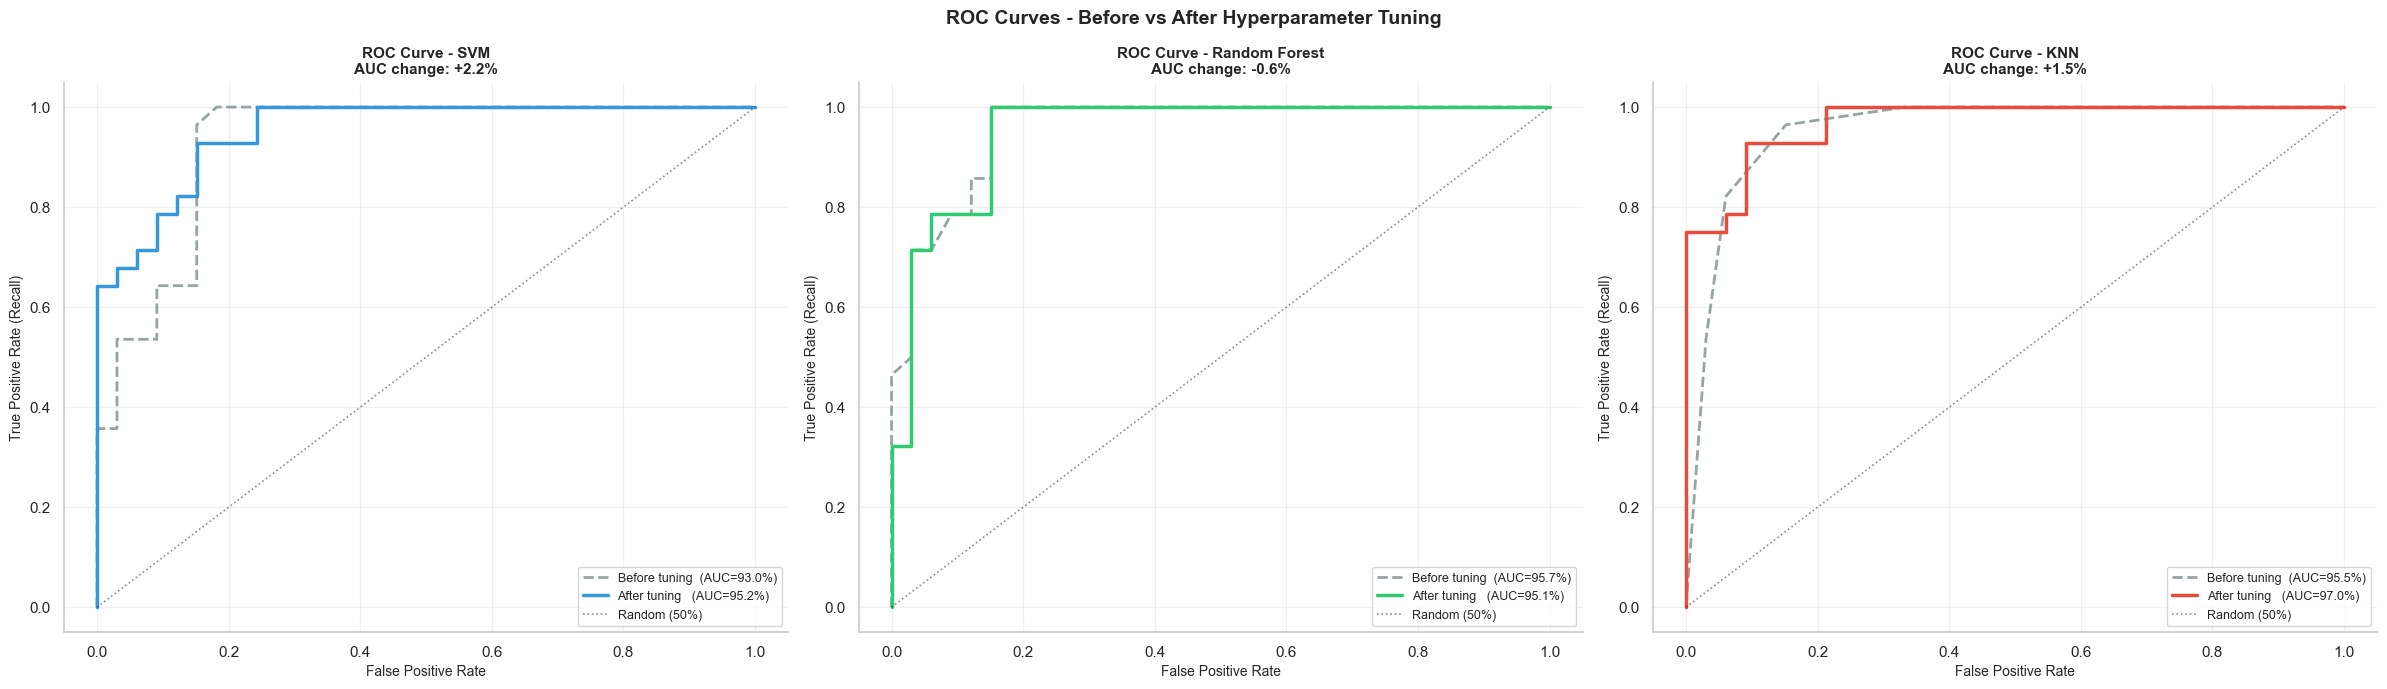

  tuning_roc_curves.png saved!


In [12]:
# ============================================================
# CELL 9 - ROC Curves: Before vs After Tuning (per model)
# ============================================================

roc_colors = ['#3498db', '#2ecc71', '#e74c3c']
n_models   = len(top3_models)

fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 7))
if n_models == 1:
    axes = [axes]

for i, (model_name, color) in enumerate(zip(top3_models, roc_colors)):
    ax           = axes[i]
    best_method  = best_method_per_model[model_name]
    feature_list = METHOD_FEATURES.get(best_method, feature_names)

    is_scaled = any(s in model_name for s in ['Logistic', 'SVM', 'KNN', 'Neural'])
    X_tr = X_train_scaled[feature_list] if is_scaled else X_train_raw[feature_list]
    X_te = X_test_scaled[feature_list]  if is_scaled else X_test_raw[feature_list]

    # Before: default model
    default_model = DEFAULT_MODELS[model_name]
    default_model.fit(X_tr, y_train)
    y_prob_before   = default_model.predict_proba(X_te)[:, 1]
    fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_before)
    auc_before       = roc_auc_score(y_test, y_prob_before) * 100

    # After: tuned model
    tuned_model = best_models_dict[model_name]
    tuned_model.fit(X_tr, y_train)
    y_prob_after    = tuned_model.predict_proba(X_te)[:, 1]
    fpr_a, tpr_a, _ = roc_curve(y_test, y_prob_after)
    auc_after        = roc_auc_score(y_test, y_prob_after) * 100

    ax.plot(fpr_b, tpr_b, '--', linewidth=2, color='#95a5a6',
            label=f'Before tuning  (AUC={auc_before:.1f}%)')
    ax.plot(fpr_a, tpr_a, '-',  linewidth=2.5, color=color,
            label=f'After tuning   (AUC={auc_after:.1f}%)')
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1.2, alpha=0.5, label='Random (50%)')

    delta_auc = auc_after - auc_before
    sign = '+' if delta_auc >= 0 else ''
    ax.set_title(f'ROC Curve - {model_name}\n'
                 f'AUC change: {sign}{delta_auc:.1f}%',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate (Recall)', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    sns.despine(ax=ax)

plt.suptitle('ROC Curves - Before vs After Hyperparameter Tuning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('  tuning_roc_curves.png saved!')


---
## Cell 10 - Confusion Matrices: Tuned Models

> Two confusion matrices per model (before and after tuning).
> We highlight the False Negatives (bottom-left cell) because in
> heart disease prediction, missing a sick patient is the most
> costly error. A decrease in FN after tuning is a strong win.

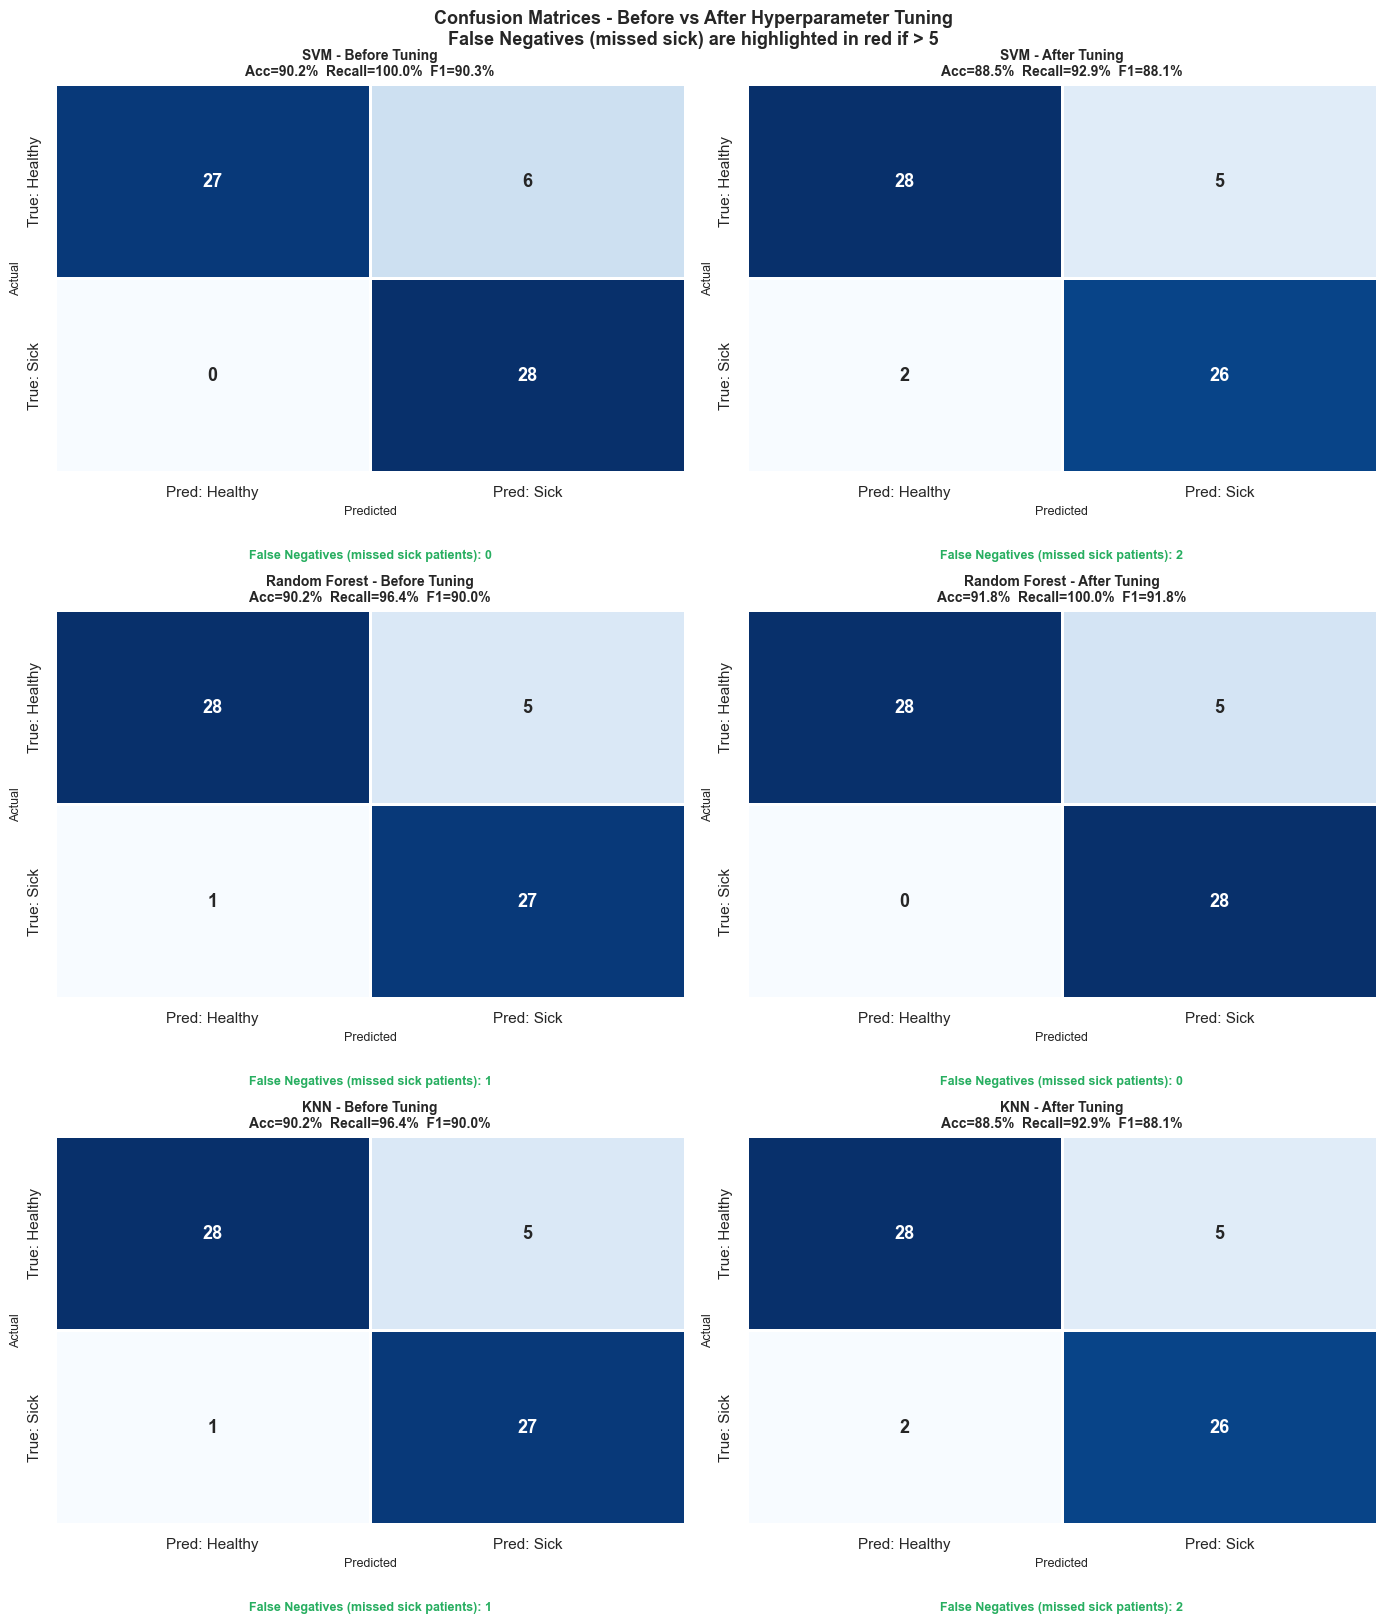

  tuning_confusion_matrices.png saved!


In [13]:
# ============================================================
# CELL 10 - Confusion Matrices: Before vs After Tuning
# ============================================================

n_models = len(top3_models)
fig, axes = plt.subplots(n_models, 2, figsize=(14, n_models * 5.5))
if n_models == 1:
    axes = [axes]

for row_idx, model_name in enumerate(top3_models):
    best_method  = best_method_per_model[model_name]
    feature_list = METHOD_FEATURES.get(best_method, feature_names)

    is_scaled = any(s in model_name for s in ['Logistic', 'SVM', 'KNN', 'Neural'])
    X_tr = X_train_scaled[feature_list] if is_scaled else X_train_raw[feature_list]
    X_te = X_test_scaled[feature_list]  if is_scaled else X_test_raw[feature_list]

    for col_idx, (use_tuned, panel_label) in enumerate([
        (False, 'Before Tuning'),
        (True,  'After Tuning')
    ]):
        ax    = axes[row_idx][col_idx]
        model = best_models_dict[model_name] if use_tuned else DEFAULT_MODELS[model_name]
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)

        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        acc = accuracy_score(y_test, y_pred) * 100
        rec = recall_score(y_test, y_pred, zero_division=0) * 100
        f1  = f1_score(y_test, y_pred, zero_division=0)     * 100

        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Healthy', 'Pred: Sick'],
            yticklabels=['True: Healthy', 'True: Sick'],
            linewidths=1, linecolor='white', cbar=False,
            annot_kws={'size': 13, 'weight': 'bold'}
        )
        ax.set_title(f'{model_name} - {panel_label}\n'
                     f'Acc={acc:.1f}%  Recall={rec:.1f}%  F1={f1:.1f}%',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)

        # Highlight FN count - most critical cell
        fn_color = '#c0392b' if fn > 5 else '#27ae60'
        ax.text(0.5, -0.22,
                f'False Negatives (missed sick patients): {fn}',
                transform=ax.transAxes, ha='center',
                fontsize=9, color=fn_color, fontweight='bold')

plt.suptitle('Confusion Matrices - Before vs After Hyperparameter Tuning\n'
             'False Negatives (missed sick) are highlighted in red if > 5',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('  tuning_confusion_matrices.png saved!')


---
## Cell 11 - Classification Reports: Tuned Models

> The classification report breaks down performance per class:
> - Class 0: Healthy patients
> - Class 1: Heart disease patients (the positive class)
>
> A model can have decent overall accuracy but still miss most sick
> patients. The per-class report reveals that immediately.

In [14]:
# ============================================================
# CELL 11 - Classification Reports: Tuned Models
# ============================================================

print('CLASSIFICATION REPORTS - Tuned Models (After Hyperparameter Tuning)')
print('All models evaluated on the held-out test set')
print()

for model_name in top3_models:
    best_method  = best_method_per_model[model_name]
    feature_list = METHOD_FEATURES.get(best_method, feature_names)

    is_scaled = any(s in model_name for s in ['Logistic', 'SVM', 'KNN', 'Neural'])
    X_tr = X_train_scaled[feature_list] if is_scaled else X_train_raw[feature_list]
    X_te = X_test_scaled[feature_list]  if is_scaled else X_test_raw[feature_list]

    tuned_model = best_models_dict[model_name]
    tuned_model.fit(X_tr, y_train)
    y_pred = tuned_model.predict(X_te)

    print('=' * 60)
    print(f'  Model         : {model_name}')
    print(f'  Feature set   : {best_method}  ({len(feature_list)} features)')
    print(f'  Best params   : {best_params_dict[model_name]}')
    print('=' * 60)
    print(classification_report(
        y_test, y_pred,
        target_names=['Healthy (0)', 'Heart Disease (1)']
    ))


CLASSIFICATION REPORTS - Tuned Models (After Hyperparameter Tuning)
All models evaluated on the held-out test set

  Model         : SVM
  Feature set   : Baseline  (22 features)
  Best params   : {'C': 50.0, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
                   precision    recall  f1-score   support

      Healthy (0)       0.93      0.85      0.89        33
Heart Disease (1)       0.84      0.93      0.88        28

         accuracy                           0.89        61
        macro avg       0.89      0.89      0.89        61
     weighted avg       0.89      0.89      0.89        61

  Model         : Random Forest
  Feature set   : Baseline  (22 features)
  Best params   : {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}
                   precision    recall  f1-score   support

      Healthy (0)       1.00      0.85      0.92        33
Heart Disease (1)       0.85      1.00      0.92       

---
## Cell 12 - Final Ranking: Tuned Models vs Baseline vs Best Pre-Tuning

> We compare three snapshots for each top model:
> 1. Baseline (no feature selection, default params)
> 2. Best pre-tuning (best feature set, default params)
> 3. After tuning (best feature set, tuned params)
>
> The combined score weights Recall most heavily (0.30), followed by
> F1-Score (0.25), ROC-AUC (0.20), Accuracy (0.15), and CV Score (0.10).
> This reflects the medical priority of catching sick patients.

Final Ranking Table - All 3 Stages:
Weighted Score = 30% Recall + 25% F1 + 20% AUC + 15% Acc + 10% CV



  OVERALL WINNER
  Model          : Random Forest
  Stage          : Post-Tuning
  Feature set    : Baseline
  Best params    : {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}
  Combined Score : 93.49%
  Recall         : 100.00%
  F1-Score       : 91.80%
  ROC-AUC        : 95.13%


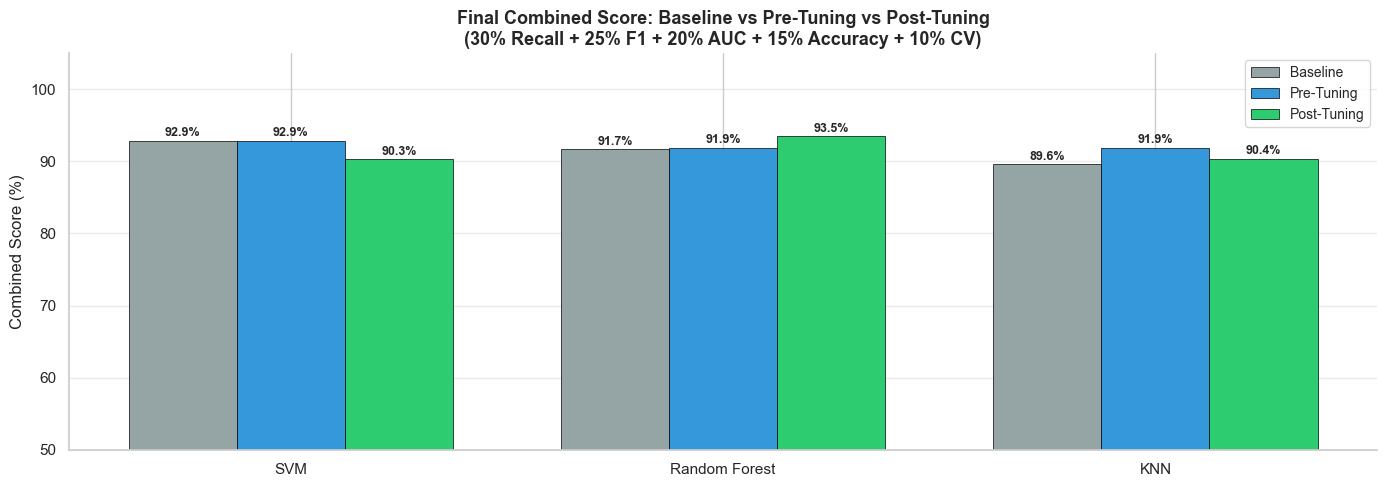

  tuning_final_ranking.png saved!


In [15]:
# ============================================================
# CELL 12 - Final Ranking: Baseline vs Pre-Tuning vs Post-Tuning
# ============================================================

# Weighted scoring - same weights as notebook 08
WEIGHTS = {
    'Recall'   : 0.30,
    'F1-Score' : 0.25,
    'ROC-AUC'  : 0.20,
    'Accuracy' : 0.15,
    'CV Score' : 0.10,
}

def combined_score(results_dict):
    """Compute the weighted combined score from a metrics dict."""
    return round(sum(
        results_dict.get(m, 0) * w for m, w in WEIGHTS.items()
    ), 2)

ranking_rows = []

for model_name in top3_models:
    best_method  = best_method_per_model[model_name]
    feature_list = METHOD_FEATURES.get(best_method, feature_names)

    # Snapshot 1: Baseline (all features, default params, from notebook 04)
    base = baseline_results.get(model_name, {})

    # Snapshot 2: Best pre-tuning (best feature set, default params)
    pre  = pre_tuning_results[model_name]

    # Snapshot 3: After tuning
    post = post_tuning_results[model_name]

    for snapshot, label in [(base, 'Baseline'), (pre, 'Pre-Tuning'), (post, 'Post-Tuning')]:
        ranking_rows.append({
            'Model'          : model_name,
            'Stage'          : label,
            'Accuracy'       : snapshot.get('Accuracy',  0),
            'Precision'      : snapshot.get('Precision', 0),
            'Recall'         : snapshot.get('Recall',    0),
            'F1-Score'       : snapshot.get('F1-Score',  0),
            'ROC-AUC'        : snapshot.get('ROC-AUC',   0),
            'CV Score'       : snapshot.get('CV Score',  0),
            'Combined Score' : combined_score(snapshot),
        })

ranking_df = pd.DataFrame(ranking_rows)

print('Final Ranking Table - All 3 Stages:')
print('Weighted Score = 30% Recall + 25% F1 + 20% AUC + 15% Acc + 10% CV')
display(
    ranking_df.set_index(['Model', 'Stage'])
    .style
    .format('{:.2f}%')
    .background_gradient(cmap='YlGn', subset=METRICS + ['Combined Score'])
    .highlight_max(color='#2ecc71', subset=['Combined Score'])
)

# Determine the overall winner
best_row   = ranking_df.loc[ranking_df['Combined Score'].idxmax()]
best_model = best_row['Model']
best_stage = best_row['Stage']

print()
print('=' * 65)
print('  OVERALL WINNER')
print('=' * 65)
print(f'  Model          : {best_model}')
print(f'  Stage          : {best_stage}')
print(f'  Feature set    : {best_method_per_model[best_model]}')
print(f'  Best params    : {best_params_dict.get(best_model, "default")}')
print(f'  Combined Score : {best_row["Combined Score"]:.2f}%')
print(f'  Recall         : {best_row["Recall"]:.2f}%')
print(f'  F1-Score       : {best_row["F1-Score"]:.2f}%')
print(f'  ROC-AUC        : {best_row["ROC-AUC"]:.2f}%')
print('=' * 65)

# Visualise final ranking - horizontal bar chart
fig, ax = plt.subplots(figsize=(14, 5))

stage_colors  = {'Baseline': '#95a5a6', 'Pre-Tuning': '#3498db', 'Post-Tuning': '#2ecc71'}
stage_labels  = ['Baseline', 'Pre-Tuning', 'Post-Tuning']
x_pos = np.arange(len(top3_models))
n_stages = len(stage_labels)
bar_w = 0.25

for si, stage in enumerate(stage_labels):
    vals = [
        ranking_df[(ranking_df['Model'] == m) &
                   (ranking_df['Stage'] == stage)]['Combined Score'].values[0]
        for m in top3_models
    ]
    offset = (si - 1) * bar_w
    bars = ax.bar(x_pos + offset, vals, bar_w,
                  label=stage, color=stage_colors[stage],
                  edgecolor='black', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(top3_models, fontsize=11)
ax.set_ylabel('Combined Score (%)', fontsize=12)
ax.set_ylim(50, 105)
ax.set_title('Final Combined Score: Baseline vs Pre-Tuning vs Post-Tuning\n'
             '(30% Recall + 25% F1 + 20% AUC + 15% Accuracy + 10% CV)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.savefig('tuning_final_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('  tuning_final_ranking.png saved!')


---
## Cell 13 - Save All Tuned Models and Results

In [16]:
# ============================================================
# CELL 13 - Save All Tuned Models and Results
# ============================================================

SAVE_DIR = 'saved_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# Tuned model objects
for model_name, model_obj in best_models_dict.items():
    safe_name = model_name.lower().replace(' ', '_')
    path = f'{SAVE_DIR}/tuned_{safe_name}.pkl'
    joblib.dump(model_obj, path)
    print(f'  [OK] tuned_{safe_name}.pkl')

# Best hyperparameters
joblib.dump(best_params_dict, f'{SAVE_DIR}/tuning_best_params.pkl')
pd.DataFrame(best_params_dict).to_csv(f'{SAVE_DIR}/tuning_best_params.csv')
print('  [OK] tuning_best_params.pkl / .csv')

# Pre and post tuning metrics
joblib.dump(pre_tuning_results,  f'{SAVE_DIR}/tuning_pre_results.pkl')
joblib.dump(post_tuning_results, f'{SAVE_DIR}/tuning_post_results.pkl')
print('  [OK] tuning_pre_results.pkl  -> metrics before tuning')
print('  [OK] tuning_post_results.pkl -> metrics after tuning')

# Full ranking table
ranking_df.to_csv(f'{SAVE_DIR}/tuning_ranking.csv', index=False)
joblib.dump(ranking_df, f'{SAVE_DIR}/tuning_ranking.pkl')
print('  [OK] tuning_ranking.csv / .pkl -> Baseline vs Pre vs Post')

# Best model info for final evaluation notebook
final_model_info = {
    'best_model_name'  : best_model,
    'best_stage'       : best_stage,
    'best_model_object': best_models_dict[best_model],
    'best_feature_list': METHOD_FEATURES[best_method_per_model[best_model]],
    'best_params'      : best_params_dict[best_model],
    'combined_score'   : best_row['Combined Score'],
}
joblib.dump(final_model_info, f'{SAVE_DIR}/tuning_final_winner.pkl')
print('  [OK] tuning_final_winner.pkl -> winner info for Phase 9')

print(f'\n  [OK] All outputs saved to: {SAVE_DIR}/')


  [OK] tuned_svm.pkl
  [OK] tuned_random_forest.pkl
  [OK] tuned_knn.pkl
  [OK] tuning_best_params.pkl / .csv
  [OK] tuning_pre_results.pkl  -> metrics before tuning
  [OK] tuning_post_results.pkl -> metrics after tuning
  [OK] tuning_ranking.csv / .pkl -> Baseline vs Pre vs Post
  [OK] tuning_final_winner.pkl -> winner info for Phase 9

  [OK] All outputs saved to: saved_data/


---
## Cell 14 - Final Summary Report

In [17]:
# ============================================================
# CELL 14 - Final Summary Report
# ============================================================

print()
print('=' * 65)
print('   PHASE 8 - HYPERPARAMETER TUNING - SUMMARY REPORT')
print('   Heart Disease Prediction | UCI Cleveland Dataset')
print('=' * 65)

print(f'\n  MODELS TUNED: {len(top3_models)}')
for m in top3_models:
    pre  = pre_tuning_results[m]
    post = post_tuning_results[m]
    delta_f1  = post['F1-Score']  - pre['F1-Score']
    delta_rec = post['Recall']    - pre['Recall']
    sign_f1   = '+' if delta_f1  >= 0 else ''
    sign_rec  = '+' if delta_rec >= 0 else ''
    print(f'\n  {m}')
    print(f'    Feature set   : {post["Feature Set"]} ({post["N Features"]} features)')
    print(f'    Best params   : {best_params_dict[m]}')
    print(f'    F1  : {pre["F1-Score"]:.2f}% -> {post["F1-Score"]:.2f}% ({sign_f1}{delta_f1:.2f}%)')
    print(f'    Recall: {pre["Recall"]:.2f}% -> {post["Recall"]:.2f}% ({sign_rec}{delta_rec:.2f}%)')
    print(f'    AUC   : {pre["ROC-AUC"]:.2f}% -> {post["ROC-AUC"]:.2f}%')

print(f'\n  OVERALL WINNER:')
print(f'    Model          : {best_model}')
print(f'    Stage          : {best_stage}')
print(f'    Combined Score : {best_row["Combined Score"]:.2f}%')
print(f'    Recall         : {best_row["Recall"]:.2f}%')
print(f'    F1-Score       : {best_row["F1-Score"]:.2f}%')

print(f'\n  PLOTS SAVED:')
for plot in ['tuning_before_after_barchart.png',
             'tuning_heatmaps.png',
             'tuning_roc_curves.png',
             'tuning_confusion_matrices.png',
             'tuning_final_ranking.png']:
    print(f'    -> {plot}')

print(f'\n  FILES SAVED TO saved_data/:')
for f in ['tuned_*.pkl (one per model)',
           'tuning_best_params.pkl / .csv',
           'tuning_pre_results.pkl',
           'tuning_post_results.pkl',
           'tuning_ranking.csv / .pkl',
           'tuning_final_winner.pkl']:
    print(f'    -> {f}')

print()
print('=' * 65)
print('  Phase 8 Complete!')
print('  Next: 10_final_evaluation.ipynb (Phase 9)')
print('=' * 65)



   PHASE 8 - HYPERPARAMETER TUNING - SUMMARY REPORT
   Heart Disease Prediction | UCI Cleveland Dataset

  MODELS TUNED: 3

  SVM
    Feature set   : Baseline (22 features)
    Best params   : {'C': 50.0, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
    F1  : 90.32% -> 88.14% (-2.18%)
    Recall: 100.00% -> 92.86% (-7.14%)
    AUC   : 93.02% -> 95.24%

  Random Forest
    Feature set   : Baseline (22 features)
    Best params   : {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}
    F1  : 90.00% -> 91.80% (+1.80%)
    Recall: 96.43% -> 100.00% (+3.57%)
    AUC   : 95.73% -> 95.13%

  KNN
    Feature set   : Emb-Union (14 features)
    Best params   : {'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
    F1  : 90.00% -> 88.14% (-1.86%)
    Recall: 96.43% -> 92.86% (-3.57%)
    AUC   : 95.51% -> 96.97%

  OVERALL WINNER:
    Model          : Random Forest
    Stage          : Post-Tuning
   